<a href="https://colab.research.google.com/github/AbdulHanoos/Drive_Guard/blob/main/Driver_Distraction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle .json to kaggle .json


{'kaggle .json': b'{"username":"akahanoos","key":"ed9ffbc8779815cf9c121113d3eb2859"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp "kaggle .json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!ls ~/.kaggle

kaggle.json


In [6]:
!kaggle competitions download -c state-farm-distracted-driver-detection -p /content/distracted_driver_data

100% 4.00G/4.00G [00:40<00:00, 106MB/s]



In [7]:
!unzip -q /content/distracted_driver_data/state-farm-distracted-driver-detection.zip -d /content/distracted_driver_data/state-farm-distracted-driver-detection

In [8]:
import os

train_path = "/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/train"

classes = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls))
])

print("Classes found:", classes)
print("Number of classes:", len(classes))

for cls in classes:
    class_path = os.path.join(train_path, cls)
    image_count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(cls, ":", image_count)

Classes found: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10
c0 : 2489
c1 : 2267
c2 : 2317
c3 : 2346
c4 : 2326
c5 : 2312
c6 : 2325
c7 : 2002
c8 : 1911
c9 : 2129


In [9]:
import os
import cv2
import numpy as np
import tensorflow as tf
from imutils import paths
import random
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import img_to_array


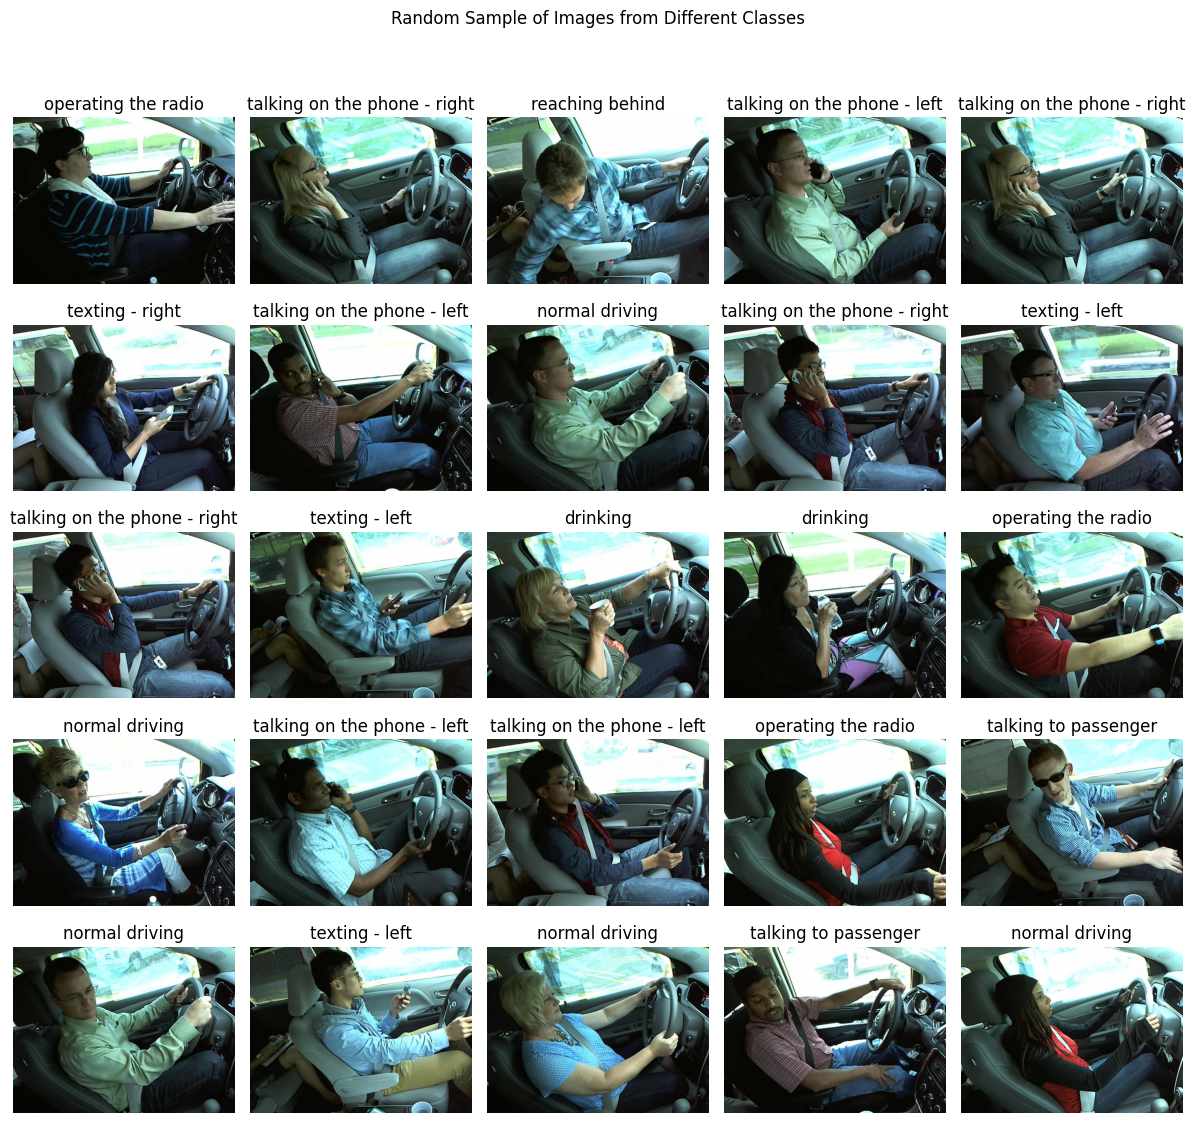

In [10]:
imagePaths = list(paths.list_images("/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/train"))
classnames = {
    "c0": "normal driving",
    "c1": "texting - right",
    "c2": "talking on the phone - right",
    "c3": "texting - left",
    "c4": "talking on the phone - left",       # Fixed: was "right"
    "c5": "operating the radio",               # Fixed: typo "ratio"
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger"
}

def display_images(image_paths, title, cols=5, num_images=25):  # Set cols and add num_images
    random.shuffle(image_paths)  # Shuffle the image paths randomly
    num_images = min(len(image_paths), num_images)  # Limit the number of images to display
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(12, 12))  # Adjust figure size to accommodate more rows
    plt.suptitle(title)

    for i, image_path in enumerate(image_paths[:num_images]):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(image_path)
        plt.imshow(img,cmap = "gray")
        label = classnames.get(os.path.basename(os.path.dirname(image_path)))
        plt.title(label)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Display a random set of images in a 5x5 grid
display_images(imagePaths, title="Random Sample of Images from Different Classes", num_images=25)


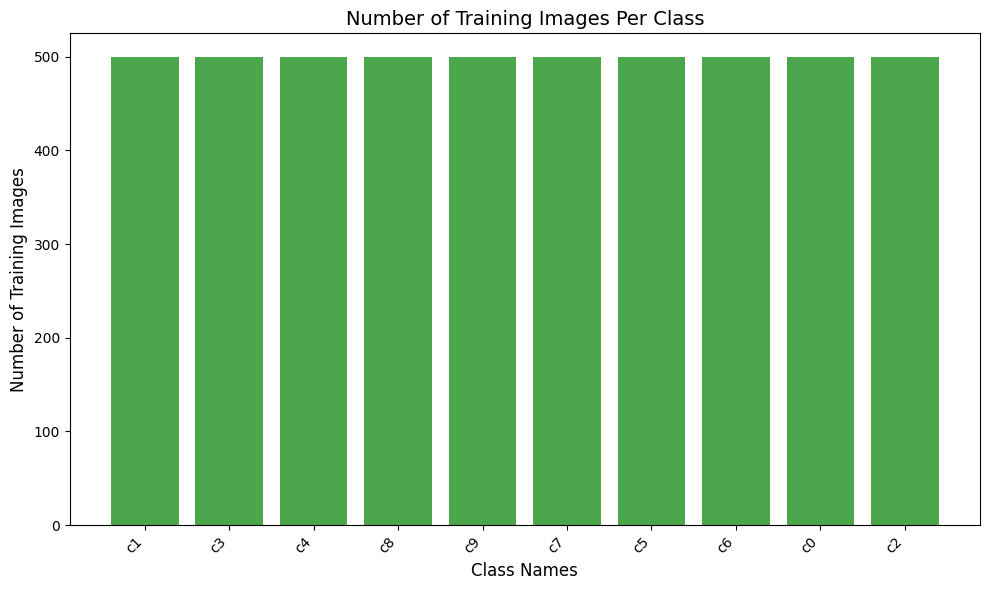

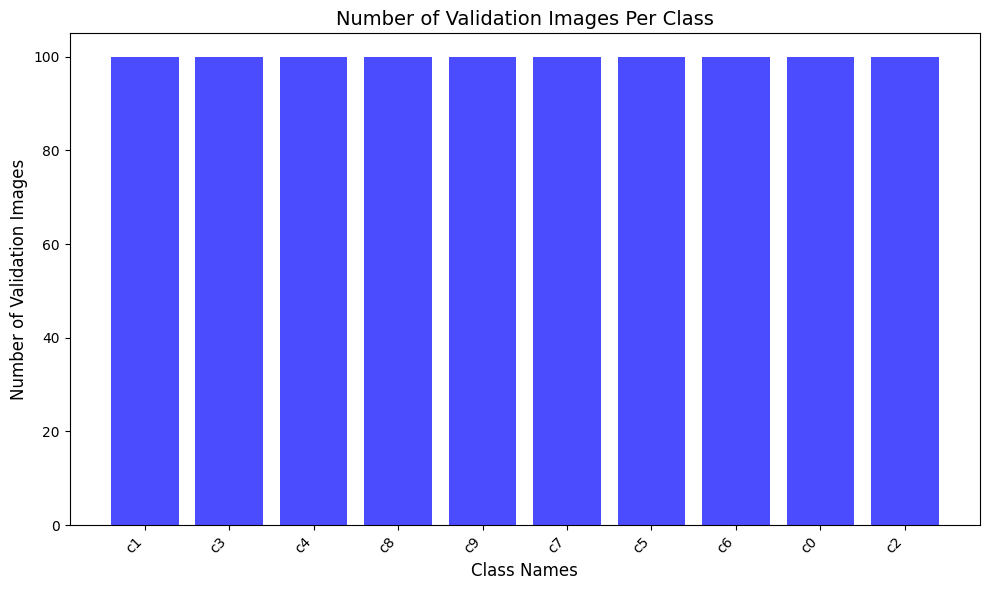

In [11]:
import os
import random
import matplotlib.pyplot as plt

# Folder containing all classes
data_folder = "/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/train"

# Number of images needed for train and validation
train_count = 500
val_count = 100

# Dictionary to store train and validation paths
train_paths = {cls: [] for cls in os.listdir(data_folder)}
val_paths = {cls: [] for cls in os.listdir(data_folder)}

# Iterate through each class folder
for cls in train_paths.keys():
    class_folder = os.path.join(data_folder, cls)
    if os.path.isdir(class_folder):
        # Get all image paths in the class folder
        images = [os.path.join(class_folder, img) for img in os.listdir(class_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
        # Shuffle the images to randomize the selection
        random.shuffle(images)
        # Split into train and validation
        train_paths[cls] = images[:train_count]
        val_paths[cls] = images[train_count:train_count + val_count]

# Count images per class for train and validation
train_counts = {cls: len(paths) for cls, paths in train_paths.items()}
val_counts = {cls: len(paths) for cls, paths in val_paths.items()}

# Visualization: Bar plot for training image counts
plt.figure(figsize=(10, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='green', alpha=0.7)
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Training Images", fontsize=12)
plt.title("Number of Training Images Per Class", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

# Visualization: Bar plot for validation image counts
plt.figure(figsize=(10, 6))
plt.bar(val_counts.keys(), val_counts.values(), color='blue', alpha=0.7)
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Validation Images", fontsize=12)
plt.title("Number of Validation Images Per Class", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

In [40]:
import cv2
import os
import numpy as np

class SimpleDatasetLoader:
  def __init__(self, preprocessors=None):
    self.preprocessors = preprocessors
    if self.preprocessors is None:
      self.preprocessors = []

  def load(self, imagePaths, verbose =- 1):
  # initialize the list of features and labels
    data = []
    labels = []

    for (i, imagePath) in enumerate(imagePaths):
      image = cv2.imread(imagePath)
      label = imagePath.split(os.path.sep)[-2]

# check to see if our preprocessors are not None
      if self.preprocessors is not None:
        for p in self.preprocessors:
          image = p.preprocess(image)

# treat our processed image as a "feature vector"
# by updating the data list followed by the labels
      data.append(image)
      labels.append(label)
      #-show.an update-every 'verbose" . images
      if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
        print("[INFO] processed {}/{}".format(i +1,
          len(imagePaths)))

# return a tuple of the data and labels
    return (np.array(data), np.array(labels))

In [34]:
import cv2
class SimplePreprocessor:
    def __init__(self, width, height, inter=cv2.INTER_AREA):
        self.width = width
        self.height = height
        self.inter = inter

    def preprocess(self, image):
      return cv2.resize(image, (self.width, self.height),
                        interpolation=self.inter)



In [37]:
from tensorflow.keras.preprocessing.image import img_to_array

class ImageToArrayPreprocessor:
    def __init__(self, dataFormat=None):
        self.dataFormat = dataFormat

    def preprocess(self, image):
        return img_to_array(image, data_format=self.dataFormat)

In [24]:
 # initialize the image preprocessors
sp = SimplePreprocessor(128,128)
iap = ImageToArrayPreprocessor()

In [35]:

# Combine all training image paths into a single list
all_train_paths = [path for paths in train_paths.values() for path in paths]

# Combine all validation image paths into a single list (optional)
all_val_paths = [path for paths in val_paths.values() for path in paths]

# Output the size of the lists
print(f"Total training images: {len(all_train_paths)}")
print(f"Total validation images: {len(all_val_paths)}")

Total training images: 5000
Total validation images: 1000


In [41]:
iap = ImageToArrayPreprocessor()
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(train_data, train_labels) = sdl.load(all_train_paths, verbose=1000)

[INFO] processed 1000/5000
[INFO] processed 2000/5000
[INFO] processed 3000/5000
[INFO] processed 4000/5000
[INFO] processed 5000/5000


In [45]:
(val_data, val_labels) = sdl.load(all_val_paths, verbose=500)

[INFO] processed 500/1000
[INFO] processed 1000/1000


In [55]:
print(type(train_data))
print(train_data.shape)

print(type(val_data))
print(val_data.shape)

<class 'numpy.ndarray'>
(5000, 128, 128, 3)
<class 'numpy.ndarray'>
(1000, 128, 128, 3)


In [56]:
[ ] # Data Normalization for all-train and validatoin all.image
train_scaled_data = train_data.astype('float32')/255
val_scaled_data = val_data.astype('float32')/255

In [57]:


print(train_scaled_data.shape)
print(val_scaled_data.shape)
print(train_scaled_data.min(), train_scaled_data.max())
print(val_scaled_data.min(), val_scaled_data.max())

(5000, 128, 128, 3)
(1000, 128, 128, 3)
0.0 1.0
0.0 1.0


In [59]:
import pandas as pd
train_val_data = {'total data':[len(train_scaled_data),len(val_scaled_data),len(train_labels),len(val_labels)]}
pd.DataFrame.from_dict(train_val_data, orient='index',columns=["train_scaled_data","train_labels","val_scaled_data","val_labels"])

,train_scaled_data,train_labels,val_scaled_data,val_labels
total data,5000,1000,5000,1000


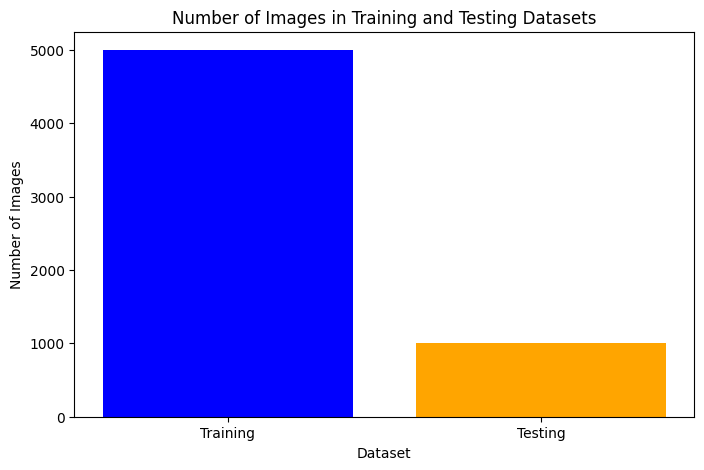

In [60]:
# Calculate the number of images for training and testing
import matplotlib.pyplot as plt
num_train_images = len(train_scaled_data)
num_test_images = len(val_scaled_data)
# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(['Training', 'Testing'], [num_train_images, num_test_images], color=['blue', 'orange'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Number of Images in Training and Testing Datasets')
plt.show()

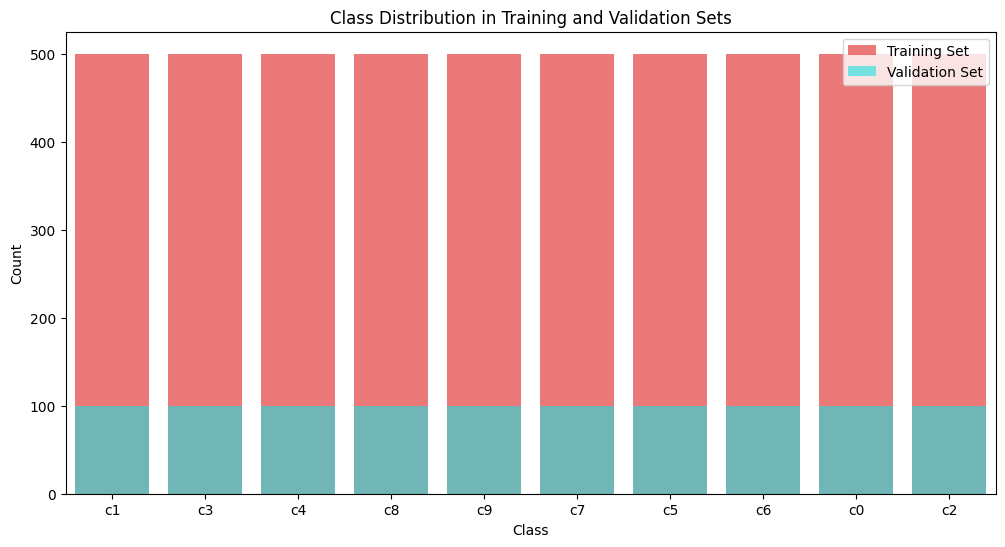

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Convert labels to DataFrames
train_df = pd.DataFrame({"Class": train_labels})
val_df = pd.DataFrame({"Class": val_labels})

plt.figure(figsize=(12, 6))

sns.countplot(
    x="Class",
    data=train_df,
    color="red",
    alpha=0.6,
    label="Training Set"
)

sns.countplot(
    x="Class",
    data=val_df,
    color="cyan",
    alpha=0.6,
    label="Validation Set"
)

plt.title("Class Distribution in Training and Validation Sets")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend()
plt.show()